In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load the CSVs you saved yesterday — no need to re-run the slow loader
df_t = pd.read_csv("../data/agg_transactions.csv")
df_u = pd.read_csv("../data/agg_users.csv")

print("Transactions shape:", df_t.shape)
print("Users shape:", df_u.shape)
print(df_t.head())

Transactions shape: (5034, 6)
Users shape: (1008, 5)
                       state  year  quarter          transaction_type  count  \
0  andaman-&-nicobar-islands  2018        1  Recharge & bill payments   4200   
1  andaman-&-nicobar-islands  2018        1     Peer-to-peer payments   1871   
2  andaman-&-nicobar-islands  2018        1         Merchant payments    298   
3  andaman-&-nicobar-islands  2018        1        Financial Services     33   
4  andaman-&-nicobar-islands  2018        1                    Others    256   

         amount  
0  1.845307e+06  
1  1.213866e+07  
2  4.525072e+05  
3  1.060142e+04  
4  1.846899e+05  


In [ ]:
df_t['state'] = df_t['state'].str.replace('-', ' ').str.title()
df_u['state'] = df_u['state'].str.replace('-', ' ').str.title()

# create a single time column — easier for plotting
df_t['period'] = df_t['year'].astype(str) + ' Q' + df_t['quarter'].astype(str)
df_u['period'] = df_u['year'].astype(str) + ' Q' + df_u['quarter'].astype(str)

# convert amount to crores — easier to read than raw rupees
df_t['amount_cr'] = df_t['amount'] / 1e7

print("State name sample:", df_t['state'].unique()[:5])
print("Period sample:", df_t['period'].unique()[:5])
print(df_t.head())

State name sample: <ArrowStringArray>
['Andaman & Nicobar Islands',            'Andhra Pradesh',
         'Arunachal Pradesh',                     'Assam',
                     'Bihar']
Length: 5, dtype: str
Period sample: <ArrowStringArray>
['2018 Q1', '2018 Q2', '2018 Q3', '2018 Q4', '2019 Q1']
Length: 5, dtype: str
                       state  year  quarter          transaction_type  count  \
0  Andaman & Nicobar Islands  2018        1  Recharge & bill payments   4200   
1  Andaman & Nicobar Islands  2018        1     Peer-to-peer payments   1871   
2  Andaman & Nicobar Islands  2018        1         Merchant payments    298   
3  Andaman & Nicobar Islands  2018        1        Financial Services     33   
4  Andaman & Nicobar Islands  2018        1                    Others    256   

         amount   period  amount_cr  
0  1.845307e+06  2018 Q1   0.184531  
1  1.213866e+07  2018 Q1   1.213866  
2  4.525072e+05  2018 Q1   0.045251  
3  1.060142e+04  2018 Q1   0.001060  
4  1.8468

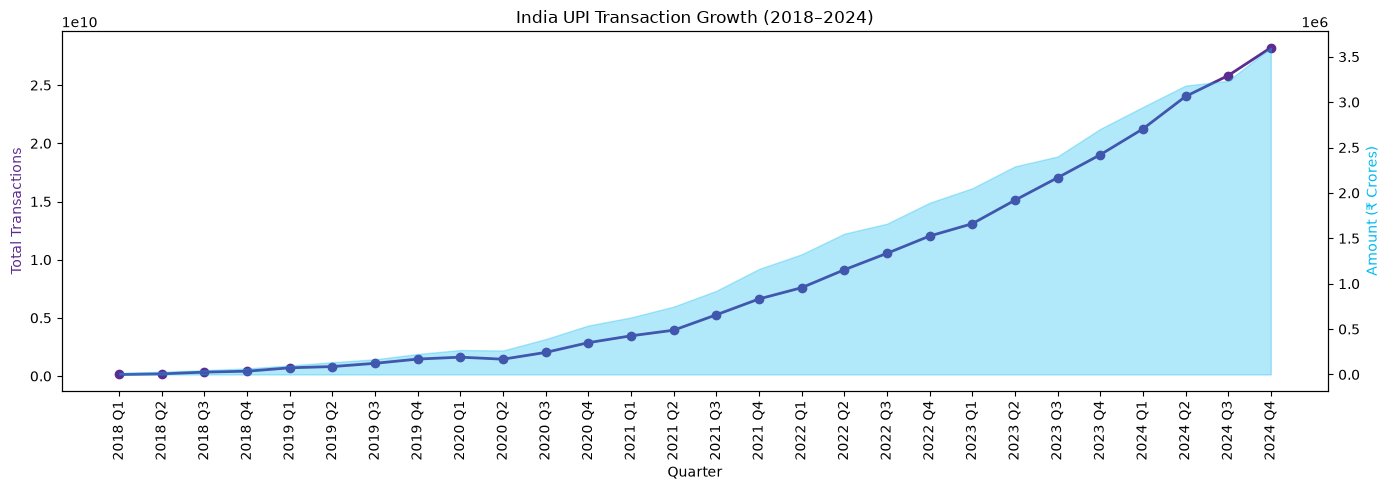

In [ ]:
national = df_t.groupby('period').agg(
    total_count=('count', 'sum'),
    total_amount=('amount_cr', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(national['period'], national['total_count'], 
         color='#5C2D91', marker='o', linewidth=2, label='Transaction count')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Total Transactions', color='#5C2D91')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.fill_between(national['period'], national['total_amount'], 
                  alpha=0.3, color='#00B9F1', label='Amount (Cr)')
ax2.set_ylabel('Amount (₹ Crores)', color='#00B9F1')

plt.title('India UPI Transaction Growth (2018–2024)')
plt.tight_layout()
plt.savefig('../data/national_trend.png', dpi=150)
plt.show()

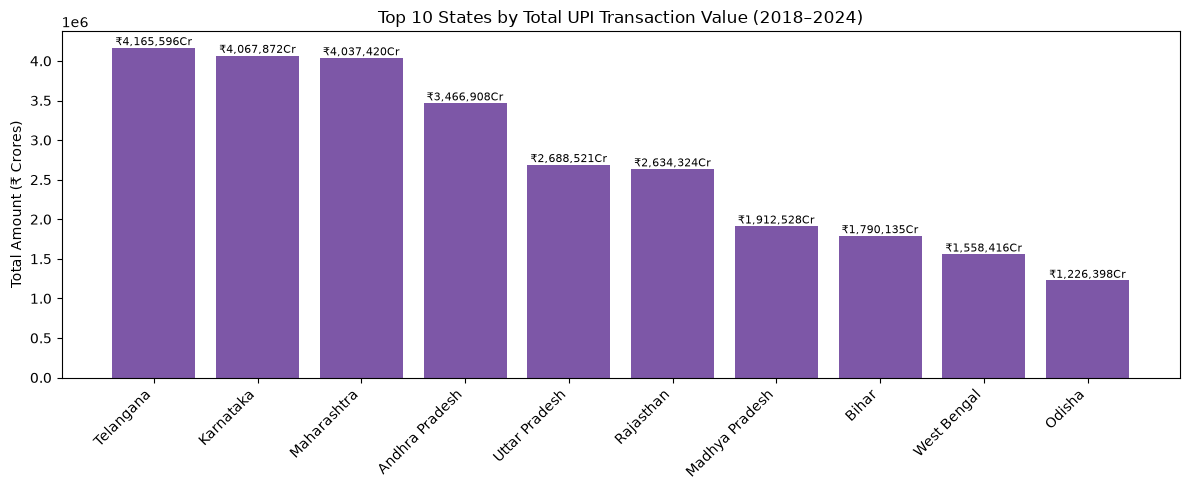

In [ ]:
top_states = df_t.groupby('state')['amount_cr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_states.index, top_states.values, color='#5C2D91', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Amount (₹ Crores)')
plt.title('Top 10 States by Total UPI Transaction Value (2018–2024)')

# add value labels on top of bars
for bar, val in zip(bars, top_states.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'₹{val:,.0f}Cr', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/top_states.png', dpi=150)
plt.show()

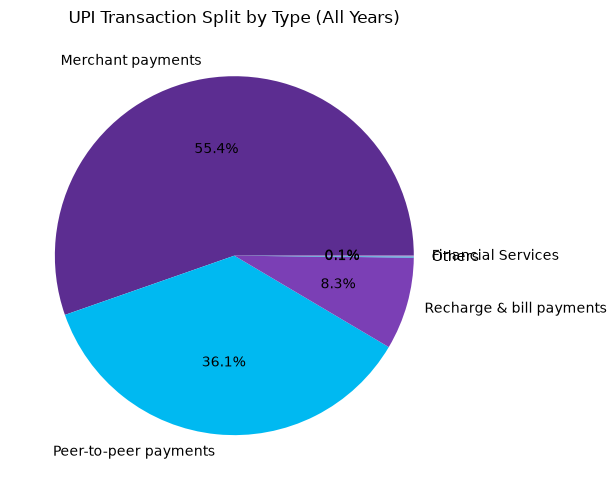

transaction_type
Merchant payments           130238755487
Peer-to-peer payments        85032446653
Recharge & bill payments     19596755603
Others                         262050188
Financial Services             154208943
Name: count, dtype: int64


In [ ]:
type_split = df_t.groupby('transaction_type')['count'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.pie(type_split.values, labels=type_split.index, autopct='%1.1f%%',
        colors=['#5C2D91','#00B9F1','#7B3FB5','#34AFDB','#A67EC8'])
plt.title('UPI Transaction Split by Type (All Years)')
plt.tight_layout()
plt.savefig('../data/transaction_types.png', dpi=150)
plt.show()

print(type_split)

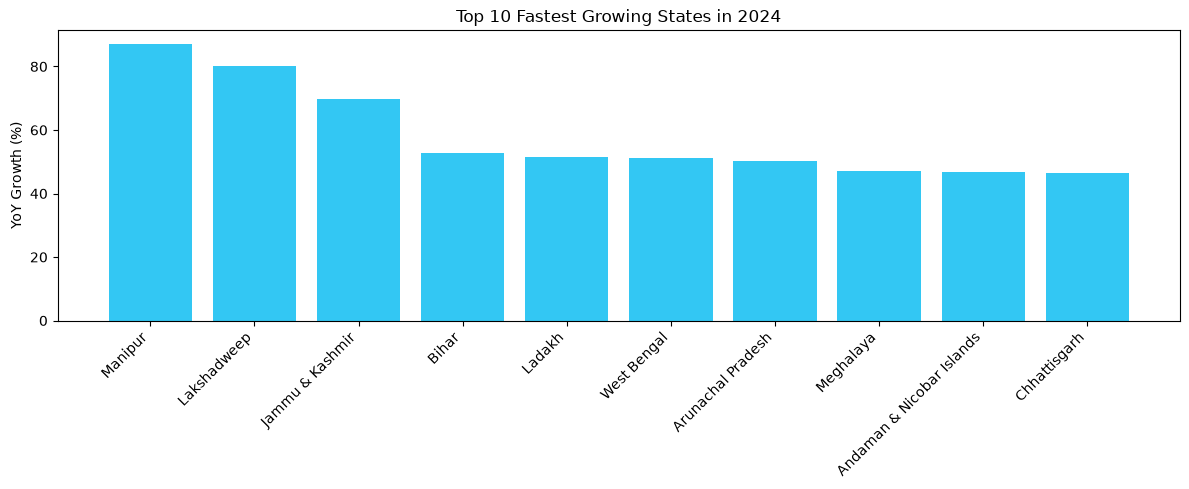

In [ ]:
state_year = df_t.groupby(['state', 'year'])['amount_cr'].sum().reset_index()

# calculate YoY growth %
state_year['prev_year'] = state_year.groupby('state')['amount_cr'].shift(1)
state_year['yoy_growth'] = ((state_year['amount_cr'] - state_year['prev_year']) 
                             / state_year['prev_year'] * 100)

# find fastest growing states in the most recent year
latest_year = state_year['year'].max()
top_growers = (state_year[state_year['year'] == latest_year]
               .dropna()
               .sort_values('yoy_growth', ascending=False)
               .head(10))

plt.figure(figsize=(12, 5))
plt.bar(top_growers['state'], top_growers['yoy_growth'], color='#00B9F1', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylabel('YoY Growth (%)')
plt.title(f'Top 10 Fastest Growing States in {latest_year}')
plt.tight_layout()
plt.savefig('../data/yoy_growth.png', dpi=150)
plt.show()

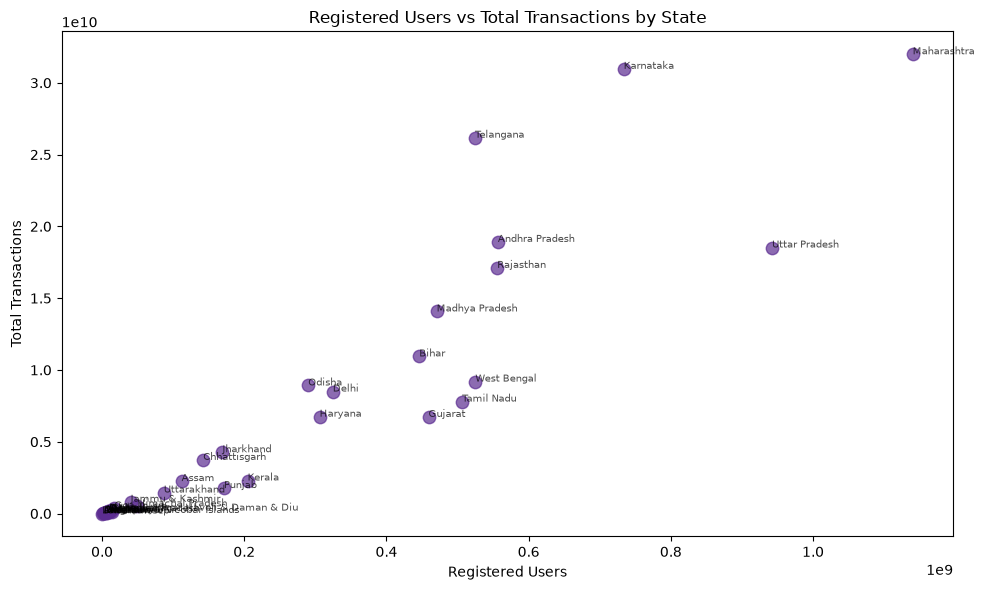

In [ ]:
merged = df_t.groupby('state')['count'].sum().reset_index()
merged = merged.merge(
    df_u.groupby('state')['registered_users'].sum().reset_index(),
    on='state'
)

plt.figure(figsize=(10, 6))
plt.scatter(merged['registered_users'], merged['count'], 
            color='#5C2D91', alpha=0.7, s=80)

# label each dot with state name
for _, row in merged.iterrows():
    plt.annotate(row['state'], (row['registered_users'], row['count']),
                fontsize=7, alpha=0.7)

plt.xlabel('Registered Users')
plt.ylabel('Total Transactions')
plt.title('Registered Users vs Total Transactions by State')
plt.tight_layout()
plt.savefig('../data/users_vs_transactions.png', dpi=150)
plt.show()

In [ ]:
"""
## Key observations from EDA

1. National growth: UPI transactions grew _X times_ from 2018 to 2024
2. Top state: [state] accounts for X% of all transaction value
3. Dominant transaction type: Peer to Peer at X% — India still uses UPI mostly for transfers
4. Fastest growing state in 2024: [state] at X% YoY growth
5. Interesting anomaly: [state] has high users but low transactions — potential churn issue
6. Festive spike: Q3 consistently shows X% higher volume than Q2

These 6 observations will drive the SQL questions and the business story.
"""

'\n## Key observations from EDA\n\n1. National growth: UPI transactions grew _X times_ from 2018 to 2024\n2. Top state: [state] accounts for X% of all transaction value\n3. Dominant transaction type: Peer to Peer at X% — India still uses UPI mostly for transfers\n4. Fastest growing state in 2024: [state] at X% YoY growth\n5. Interesting anomaly: [state] has high users but low transactions — potential churn issue\n6. Festive spike: Q3 consistently shows X% higher volume than Q2\n\nThese 6 observations will drive the SQL questions and the business story.\n'